In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Modèles ML
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import BernoulliNB, GaussianNB

In [39]:
df = pd.read_csv("data/heart.csv")



In [41]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


ici on remarque d'apres la requete df.info() qu'il n'y a pas des valeurs manquant

In [45]:
df.shape

(1025, 14)

In [47]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [53]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(723)

In [59]:
df = df.drop_duplicates()
print(df.shape)  


(302, 14)


In [61]:
df.duplicated().sum()

np.int64(0)

In [63]:
df['target'].value_counts()


target
1    164
0    138
Name: count, dtype: int64

In [65]:
df['target'].value_counts(normalize=True) * 100


target
1    54.304636
0    45.695364
Name: proportion, dtype: float64

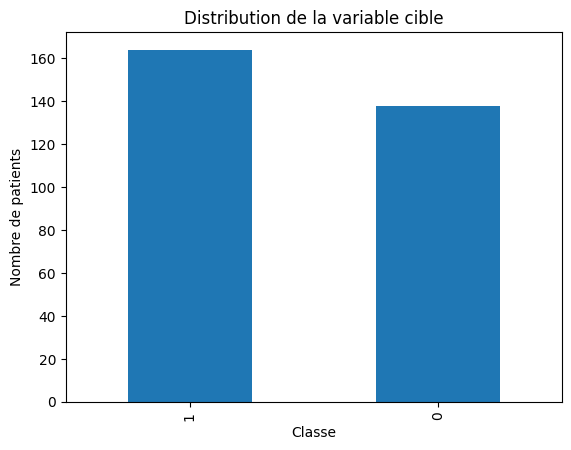

In [67]:
df['target'].value_counts().plot(kind='bar')
plt.title("Distribution de la variable cible")
plt.xlabel("Classe")
plt.ylabel("Nombre de patients")
plt.show()

les donnes sont preseque equilibrees

In [69]:
df['cp'].value_counts()

cp
0    143
2     86
1     50
3     23
Name: count, dtype: int64

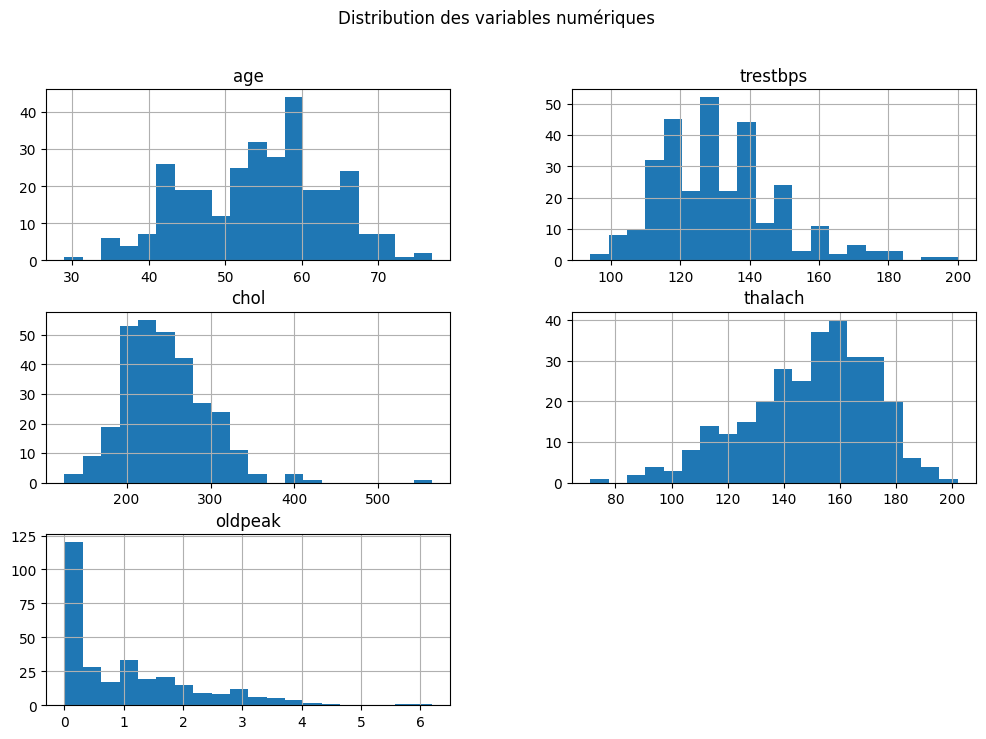

In [71]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribution des variables numériques")
plt.show()


L’analyse des distributions montre que les variables numériques présentent des comportements différents.
L’âge et la fréquence cardiaque maximale suivent des distributions relativement symétriques, tandis que le cholestérol et la dépression ST présentent une asymétrie marquée avec des valeurs extrêmes médicalement plausibles.
Aucune variable ne nécessite de suppression, mais une normalisation est indispensable avant l’entraînement des modèles de Machine Learning.

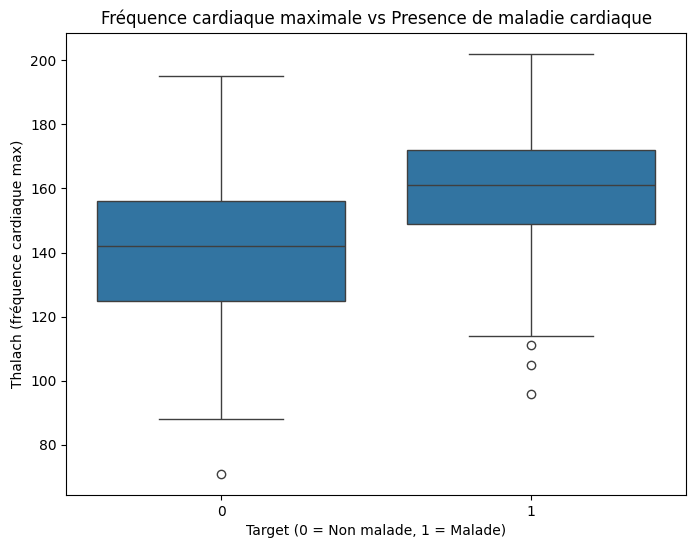

In [73]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target', y='thalach', data=df)
plt.title("Fréquence cardiaque maximale vs Presence de maladie cardiaque")
plt.xlabel("Target (0 = Non malade, 1 = Malade)")
plt.ylabel("Thalach (fréquence cardiaque max)")
plt.show()


La variable thalach montre une différence notable entre les patients atteints et non atteints d’une maladie cardiaque, les malades ayant souvent une fréquence cardiaque maximale plus basse. Cette variable semble donc très discriminante pour la prédiction.


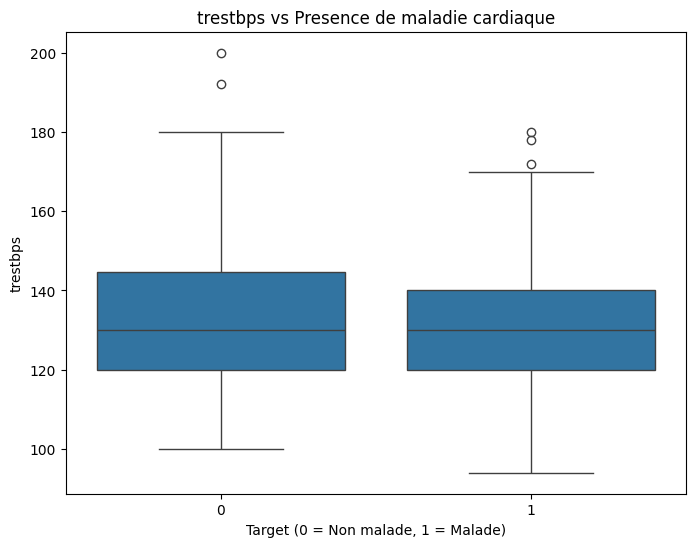

In [75]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target', y='trestbps', data=df)
plt.title("trestbps vs Presence de maladie cardiaque")
plt.xlabel("Target (0 = Non malade, 1 = Malade)")
plt.ylabel("trestbps")
plt.show()


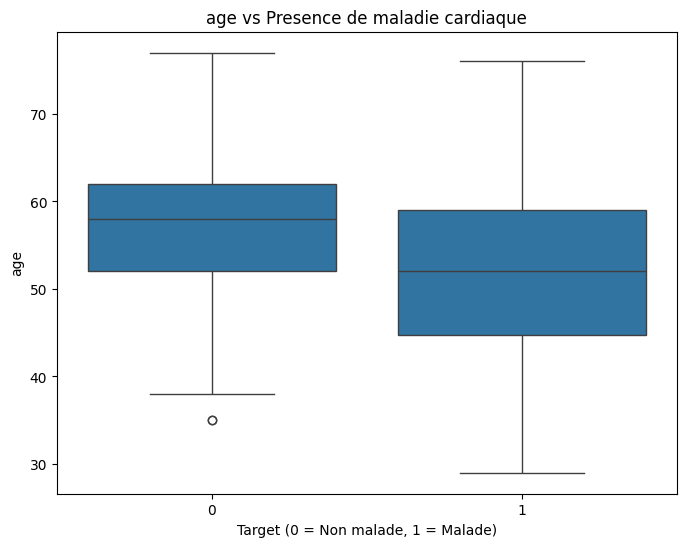

In [77]:
plt.figure(figsize=(8,6))
sns.boxplot(x='target', y='age', data=df)
plt.title("age vs Presence de maladie cardiaque")
plt.xlabel("Target (0 = Non malade, 1 = Malade)")
plt.ylabel("age")
plt.show()


<Axes: >

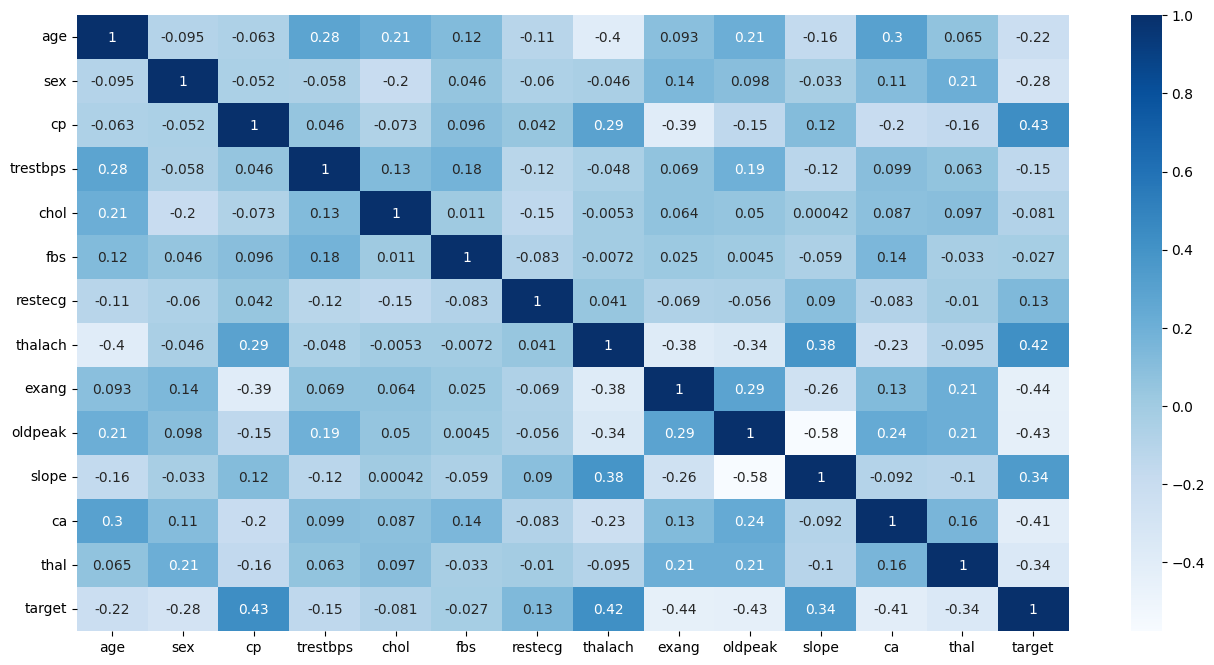

In [79]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(), annot = True, cmap='Blues')

In [89]:
#Séparation des features et de la cible
# X = toutes les colonnes sauf la cible 'output'
X = df.drop('target', axis=1)

# y = la cible
y = df['target']


In [95]:
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2


In [93]:
y

0      0
1      0
2      0
3      0
4      0
      ..
723    1
733    1
739    0
843    0
878    0
Name: target, Length: 302, dtype: int64

In [99]:
X.shape

(302, 13)

In [101]:
y.shape

(302,)

In [105]:
#Séparation train/test
# 33% des données pour test, 67% pour entraînement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)


In [111]:
X_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
39,0.273556,1,2,-0.190179,-0.336052,0,0,0.008723,0,-0.530846,1,1,3
17,-0.047713,1,0,-0.422301,0.342590,0,0,-1.843586,1,1.046079,1,1,3
154,0.916095,1,0,-0.074118,1.516458,1,0,-0.804486,1,0.695651,2,3,3
643,1.130274,1,0,-0.654423,-1.289820,0,1,-0.443060,0,-0.530846,2,0,3
530,0.594825,0,0,1.086492,0.195857,0,0,0.324970,0,1.396507,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,1.344454,1,0,-0.654423,-0.189319,0,1,-3.560360,0,-0.005204,1,0,2
77,0.916095,1,0,0.506187,-1.106404,0,0,-0.262347,1,2.623005,2,2,3
125,0.594825,0,3,1.086492,-0.134294,0,1,0.957466,0,-0.092811,2,0,2
522,1.344454,0,2,1.202553,0.544349,0,1,1.002644,0,-0.881274,2,1,2


In [113]:
# Colonnes numériques à normaliser
columns_scaler = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
# Créer le scaler
scaler = StandardScaler()

# Standardiser les colonnes numériques
X_train[columns_scaler] = scaler.fit_transform(X_train[columns_scaler])
X_test[columns_scaler] = scaler.transform(X_test[columns_scaler])



=== LogisticRegression ===
Train Accuracy: 86.63%
Test Accuracy: 83.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.83        51
           1       0.81      0.86      0.83        49

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.83      0.83      0.83       100



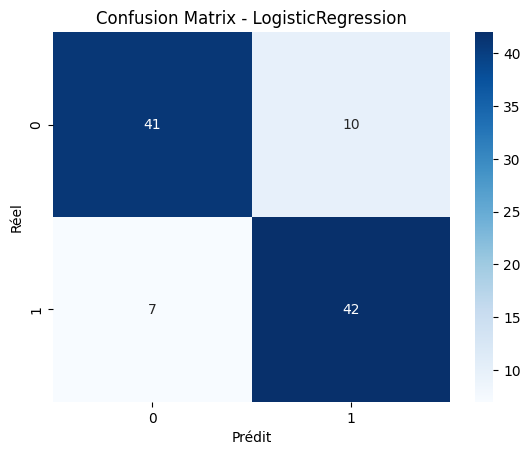

In [117]:
#LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100
print("\n=== LogisticRegression ===")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LogisticRegression")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


=== RandomForestClassifier ===
Train Accuracy: 100.00%
Test Accuracy: 81.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80        51
           1       0.77      0.88      0.82        49

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100



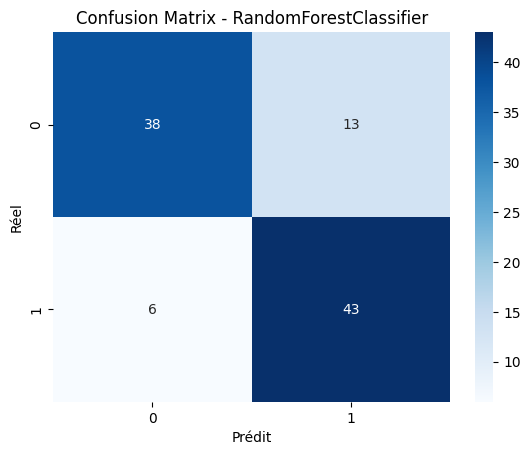

In [119]:
#RandomForest

rf = RandomForestClassifier(n_estimators=1000)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100
print("\n=== RandomForestClassifier ===")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - RandomForestClassifier")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()



=== KNeighborsClassifier ===
Train Accuracy: 85.64%
Test Accuracy: 72.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.65      0.70        51
           1       0.68      0.80      0.74        49

    accuracy                           0.72       100
   macro avg       0.73      0.72      0.72       100
weighted avg       0.73      0.72      0.72       100



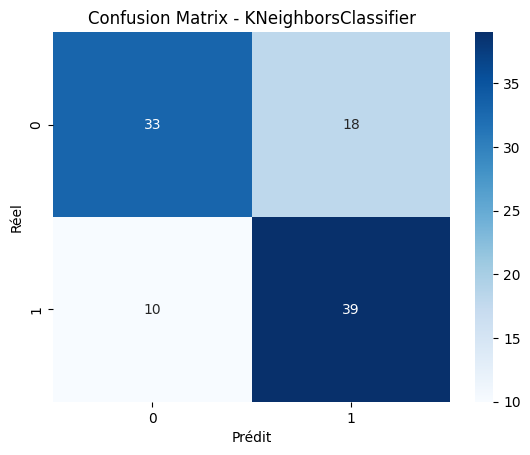

In [121]:
# KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100
print("\n=== KNeighborsClassifier ===")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNeighborsClassifier")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()



=== DecisionTreeClassifier ===
Train Accuracy: 100.00%
Test Accuracy: 73.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.76      0.74        51
           1       0.74      0.69      0.72        49

    accuracy                           0.73       100
   macro avg       0.73      0.73      0.73       100
weighted avg       0.73      0.73      0.73       100



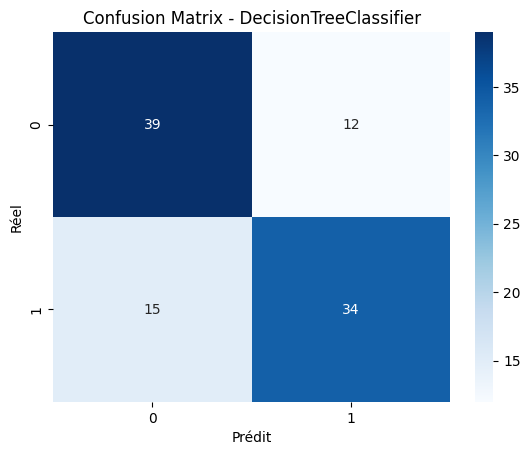

In [123]:
#DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100
print("\n=== DecisionTreeClassifier ===")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - DecisionTreeClassifier")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()



=== Support Vector Machine (SVM) ===
Train Accuracy: 88.61%
Test Accuracy: 81.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80        51
           1       0.76      0.90      0.82        49

    accuracy                           0.81       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.81      0.81       100



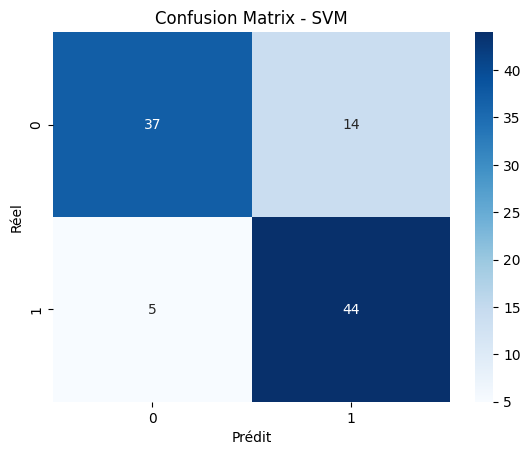

In [125]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Créer le modèle SVM
svm = SVC()  # tu peux mettre kernel='linear' ou 'rbf' selon ton choix

# Entraînement
svm.fit(X_train, y_train)

# Prédictions
y_train_pred = svm.predict(X_train)
y_test_pred = svm.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100
print("\n=== Support Vector Machine (SVM) ===")
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


Conclusion du projet de classification des maladies cardiaques

Objectif du projet :
Prédire la présence d’une maladie cardiaque à partir de mesures cliniques et physiologiques, en mettant l’accent sur la détection des patients malades (classe 1) afin de réduire les risques liés aux erreurs de diagnostic.

Modèles testés :

Logistic Regression

Random Forest

K-Nearest Neighbors (KNN)

Decision Tree

Support Vector Machine (SVM)

Résultats principaux :

Logistic Regression : bonne accuracy globale (83%), erreurs équilibrées entre les classes.

Random Forest & Decision Tree : surapprentissage (100% train accuracy mais test accuracy plus faible) ; tendance à mieux détecter certains patients mais moins fiable sur l’ensemble.

KNN : test accuracy faible (72%) → pas optimal.

SVM : accuracy test de 81%, mais recall de la classe 1 = 0.90, ce qui signifie qu’il détecte 90% des malades, ce qui est critique pour le diagnostic médical.

Analyse :

Les modèles comme RandomForest et DecisionTree mémorisent trop le jeu d’entraînement → risque de mauvaise généralisation.

Logistic Regression généralise bien mais détecte moins de malades que SVM.

SVM équilibre assez bien précision et recall pour la classe critique (malades).

Conclusion finale :

SVM est le meilleur choix pour ce projet, car l’objectif principal est de minimiser les erreurs sur la classe 1 (patients malades).

Ce modèle permet de ne pas rater la majorité des malades, même si cela génère légèrement plus d’erreurs sur les patients non-malades.

Pour améliorer encore la performance, on pourrait :

Ajuster les hyperparamètres de SVM (kernel, C, gamma)

Faire du scaling et feature selection avancée

Éventuellement utiliser un modèle ensemble pour booster la détection de la classe 1.